# Supply Chain Delivery Delay Analysis — DataCo Dataset

## Business Problem

Sebuah perusahaan e-commerce global mengelola pengiriman pesanan lintas region, dan mengalami **ketidakkonsistenan waktu pengiriman**: durasi aktual sering menyimpang dari jadwal yang dijanjikan (*Days for shipment (scheduled)*), yang berpotensi menimbulkan biaya customer service, refund, dan menurunkan kepercayaan pelanggan.

Alih-alih hanya mengklasifikasikan pesanan sebagai "telat / tidak telat", analisis ini mengambil pertanyaan yang lebih operasional:

> **Seberapa banyak (dalam hari) sebuah pesanan diperkirakan akan telat, faktor apa yang paling mempengaruhinya, dan apakah secara finansial masuk akal untuk melakukan intervensi (mempercepat pengiriman) pada pesanan-pesanan berisiko tinggi?**

### Desired Outcome
1. Model **regresi** yang memprediksi *delay_days* (jumlah hari lebih cepat/lambat dari jadwal), bukan sekadar label biner.
2. Pemahaman *why* kontribusi tiap faktor terhadap prediksi delay (explainability).
3. Simulasi **cost-sensitive**: apakah mengubah shipping mode untuk pesanan berisiko tinggi secara finansial menguntungkan?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
PALETTE = "mako"


## 1. Load & Clean Data

Berbeda dari pendekatan umum yang membuang kolom `Latitude`/`Longitude` karena dianggap tidak relevan, di sini kedua kolom tersebut **dipertahankan** — akan dipakai untuk analisis geospasial dan sebagai fitur model (lihat Bagian 3 & 5).

In [ ]:
# Link asli Google Sheets
sheet_url = "https://docs.google.com/spreadsheets/d/1pWKUiz4kOYDLhPhj2bDddYjgnErSR62OOn3C4gSKPL4/edit?usp=sharing"

# Mengubah link menjadi format export CSV
csv_url = sheet_url.replace("/edit?usp=sharing", "/export?format=csv")

# Membaca data langsung dari URL CSV
df = pd.read_csv(csv_url, encoding="latin1")

print("Shape awal:", df.shape)

drop_cols = [
    "Product Description",
    "Product Image",
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Customer Zipcode",
    "Order Zipcode",
    "Category Id",
    "Department Id",
    "Order Id",
    "Order Customer Id",
    "Customer Id",
    "Product Card Id",
    "Product Category Id",
    "Benefit per order",
    "Product Status",
    "Customer City",
    "Customer State",
    "Order City",
    "Order State",
    "Order Item Cardprod Id",
    "Order Item Id",
    "Order Item Total",
    "Order Item Product Price",
    "Product Name",
]

# Menghapus kolom yang tidak diperlukan
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Buang pesanan yang dibatalkan pengirimannya -> tidak relevan untuk analisis delay
if "Delivery Status" in df.columns:
  df = df[df["Delivery Status"] != "Shipping canceled"].reset_index(drop=True)

for c in ["order date (DateOrders)", "shipping date (DateOrders)"]:
  if c in df.columns:
    df[c] = pd.to_datetime(df[c], errors="coerce")

print("Shape setelah cleaning:", df.shape)
df.head()

Shape awal: (180519, 53)
Shape setelah cleaning: (172765, 26)


,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,...,Order Item Discount Rate,Order Item Profit Ratio,Order Item Quantity,Sales,Order Profit Per Order,Order Region,Order Status,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,0.04,0.29,1,327.75,91.250000,Southeast Asia,COMPLETE,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,0.05,-0.80,1,327.75,-249.089996,South Asia,PENDING,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,0.06,-0.80,1,327.75,-247.779999,South Asia,CLOSED,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,...,0.07,0.08,1,327.75,22.860001,Oceania,COMPLETE,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,...,0.09,0.45,1,327.75,134.210007,Oceania,PENDING_PAYMENT,327.75,2018-01-15 11:24:00,Standard Class


## 2. Target: `delay_days` (Regresi, Bukan Klasifikasi Biner)

```
delay_days = Days for shipping (real) - Days for shipment (scheduled)
```

Nilai positif = telat sekian hari, nol = tepat waktu, negatif = lebih cepat dari jadwal. Target ini jauh lebih actionable dibanding label biner `Late_delivery_risk` bawaan dataset — tim ops bisa tahu **seberapa parah**, bukan cuma ya/tidak.

Kolom `Days for shipping (real)`, `Delivery Status`, dan `Late_delivery_risk` **tidak dipakai sebagai fitur model** karena merupakan turunan langsung dari target (data leakage) — hanya dipakai untuk validasi/EDA.

In [ ]:
df['delay_days'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

print(df['delay_days'].describe())
print("\n% pesanan telat (>0 hari):", round((df['delay_days'] > 0).mean()*100, 2), "%")
print("% pesanan lebih cepat (<0 hari):", round((df['delay_days'] < 0).mean()*100, 2), "%")


count    172765.000000
mean          0.565496
std           1.493242
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: delay_days, dtype: float64

% pesanan telat (>0 hari): 57.29 %
% pesanan lebih cepat (<0 hari): 24.07 %


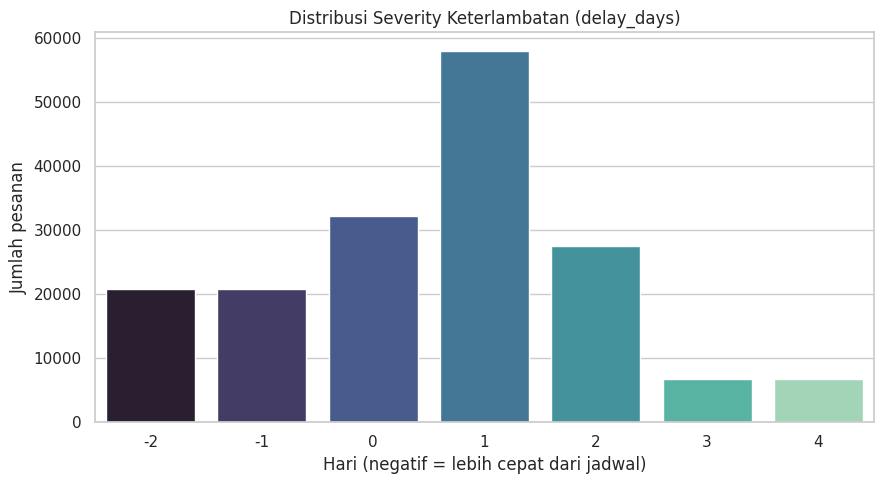

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(x='delay_days', data=df, palette=PALETTE, ax=ax)
ax.set_title('Distribusi Severity Keterlambatan (delay_days)')
ax.set_xlabel('Hari (negatif = lebih cepat dari jadwal)')
ax.set_ylabel('Jumlah pesanan')
plt.tight_layout()
plt.show()


**Insight:** Distribusi ini menunjukkan lebih dari sekadar "% telat" — terlihat berapa banyak pesanan yang justru dikirim *lebih cepat* dari jadwal, informasi yang hilang total kalau target hanya biner.

## 3. Profitabilitas vs Severity Delay (per Shipping Mode)

Bagian ini memperdalam analisis profitabilitas dengan memecahnya per shipping mode dan severity delay, bukan sekadar delay vs profit secara umum.

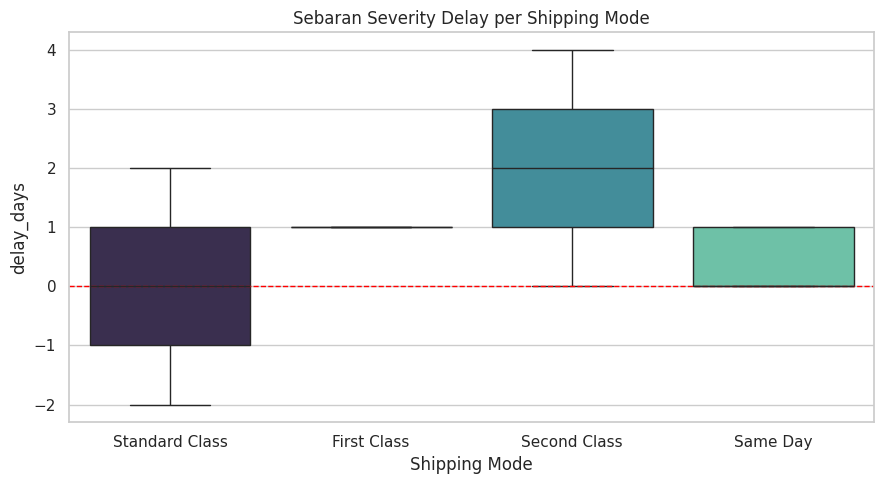

                    mean  median       std
Shipping Mode                             
Second Class    1.993167     2.0  1.414040
First Class     1.000000     1.0  0.000000
Same Day        0.479285     0.0  0.499598
Standard Class -0.006301     0.0  1.418669


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(x='Shipping Mode', y='delay_days', data=df, palette=PALETTE, ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Sebaran Severity Delay per Shipping Mode')
plt.tight_layout()
plt.show()

print(df.groupby('Shipping Mode')['delay_days'].agg(['mean','median','std']).sort_values('mean', ascending=False))


In [ ]:
profit_by_mode = df.groupby('Shipping Mode')[['Order Profit Per Order','Sales']].mean().sort_values('Order Profit Per Order', ascending=False)
print(profit_by_mode)


                Order Profit Per Order       Sales
Shipping Mode                                     
First Class                  23.256392  203.977994
Standard Class               22.033099  204.461599
Second Class                 21.382638  202.942128
Same Day                     20.895527  199.598860


**Insight:** Rata-rata profit per order **tidak jauh berbeda** antar shipping mode di dataset ini — artinya dataset tidak menyediakan data biaya carrier aktual per mode. Ini penting dicatat karena akan mempengaruhi asumsi yang dipakai pada simulasi cost-sensitive di Bagian 7.

## 4. Analisis Geospasial (Differentiator Tidak Ada di Notebook Referensi)

Menggunakan `Latitude`/`Longitude` pelanggan untuk memetakan rata-rata delay secara spasial, bukan hanya agregat per `Order Region`/`Country` dalam bentuk bar chart.

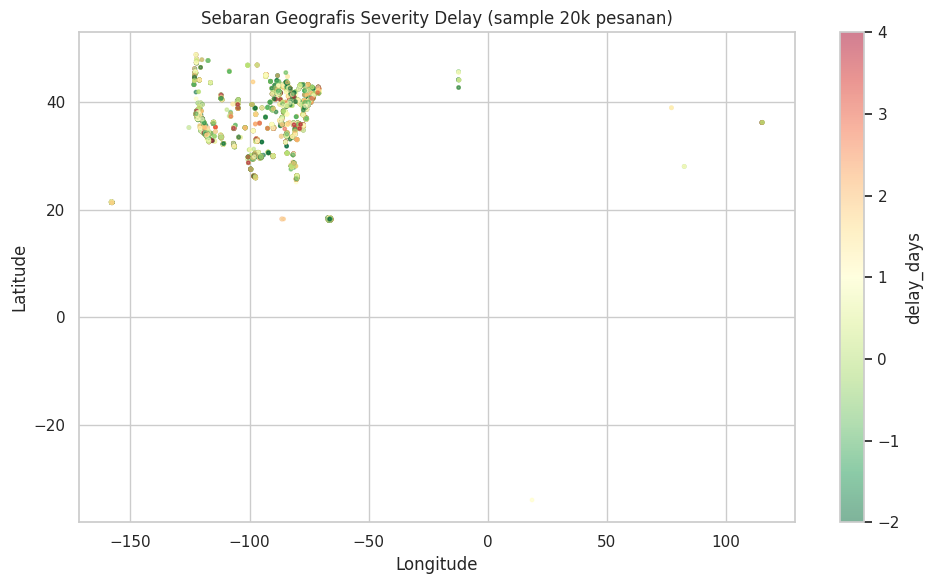

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sample = df.sample(min(20000, len(df)), random_state=42)
sc = ax.scatter(sample['Longitude'], sample['Latitude'], c=sample['delay_days'],
                 cmap='RdYlGn_r', s=6, alpha=0.5, vmin=-2, vmax=4)
plt.colorbar(sc, label='delay_days')
ax.set_title('Sebaran Geografis Severity Delay (sample 20k pesanan)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()


In [ ]:
geo_risk = df.groupby('Order Region')['delay_days'].agg(['mean','count']).sort_values('mean', ascending=False)
print(geo_risk)


                     mean  count
Order Region                    
Central Asia     0.630996    542
Central Africa   0.628094   1616
US Center        0.601097   5653
South of  USA    0.596628   3855
South Asia       0.596512   7455
Western Europe   0.596358  25867
East Africa      0.588995   1781
Eastern Europe   0.585469   3785
East of USA      0.585311   6617
West Asia        0.575009   5746
Eastern Asia     0.564033   6973
West of USA      0.559842   7595
Oceania          0.559231   9733
Central America  0.557886  27174
North Africa     0.557032   3086
South America    0.555979  14184
Southeast Asia   0.555276   9136
West Africa      0.548026   3571
Northern Europe  0.543367   9408
Caribbean        0.539681   7951
Southern Europe  0.512846   9030
Southern Africa  0.480000   1100
Canada           0.378170    907


**Insight:** Peta spasial menunjukkan sebaran risiko yang lebih granular dibanding agregat per region — ada variasi di dalam satu region yang tidak tertangkap kalau hanya melihat rata-rata per `Order Region`. Fitur `Latitude`/`Longitude` juga akan diuji kontribusinya secara kuantitatif lewat SHAP di Bagian 6.

## 5. Feature Engineering

Fitur tambahan yang dibangun khusus untuk model regresi (tidak ada di notebook referensi):

- **Waktu siklikal**: bulan, hari-dalam-minggu, dan jam order dikodekan sebagai sin/cos (bukan kategori linear biasa) supaya model menangkap sifat siklis waktu.
- **`dist_from_centroid`**: proxy jarak geografis pesanan dari titik pusat (centroid) seluruh pesanan — sebagai proksi kompleksitas pengiriman karena dataset tidak menyediakan koordinat gudang asal.

In [ ]:
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_weekday'] = df['order date (DateOrders)'].dt.weekday
df['order_hour'] = df['order date (DateOrders)'].dt.hour

df['month_sin'] = np.sin(2*np.pi*df['order_month']/12)
df['month_cos'] = np.cos(2*np.pi*df['order_month']/12)
df['weekday_sin'] = np.sin(2*np.pi*df['order_weekday']/7)
df['weekday_cos'] = np.cos(2*np.pi*df['order_weekday']/7)
df['hour_sin'] = np.sin(2*np.pi*df['order_hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['order_hour']/24)

lat0, lon0 = df['Latitude'].mean(), df['Longitude'].mean()
df['dist_from_centroid'] = np.sqrt((df['Latitude']-lat0)**2 + (df['Longitude']-lon0)**2)

df[['month_sin','month_cos','weekday_sin','weekday_cos','hour_sin','hour_cos','dist_from_centroid']].describe()


,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos,dist_from_centroid
count,1.727650e+05,1.727650e+05,172765.000000,172765.000000,1.727650e+05,1.727650e+05,172765.000000
mean,2.252970e-02,-2.957265e-02,-0.003262,-0.001481,1.145616e-03,1.070413e-03,21.143206
std,7.104563e-01,7.027628e-01,0.706793,0.707415,7.067536e-01,7.074622e-01,10.375161
min,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,0.975409
25%,-5.000000e-01,-8.660254e-01,-0.781831,-0.900969,-7.071068e-01,-7.071068e-01,13.676818
50%,1.224647e-16,-1.836970e-16,0.000000,-0.222521,1.224647e-16,6.123234e-17,21.796874
75%,8.660254e-01,5.000000e-01,0.781831,0.623490,7.071068e-01,7.071068e-01,22.095510
max,1.000000e+00,1.000000e+00,0.974928,1.000000,1.000000e+00,1.000000e+00,200.280366


## 6. Modeling: Regresi `delay_days`

Membandingkan 3 model regresi: Linear Regression (baseline), Random Forest Regressor, dan XGBoost Regressor. Fitur yang berpotensi *leakage* (`Days for shipping (real)`, `Delivery Status`, `Late_delivery_risk`) sengaja dikeluarkan.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

num_cols = ['Sales per customer','Order Item Discount Rate','Order Item Profit Ratio','Order Item Quantity',
            'Sales','Order Profit Per Order','Product Price','Latitude','Longitude','dist_from_centroid',
            'Days for shipment (scheduled)','month_sin','month_cos','weekday_sin','weekday_cos','hour_sin','hour_cos']
cat_cols = ['Type','Category Name','Customer Segment','Department Name','Market','Order Region',
            'Customer Country','Order Country','Shipping Mode','Order Status']

X = df[num_cols + cat_cols].copy()
cat_maps = {}
for c in cat_cols:
    X[c] = df[c].astype('category')
    cat_maps[c] = dict(enumerate(X[c].cat.categories))
    X[c] = X[c].cat.codes
y = df['delay_days']

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (138212, 27)  Test: (34553, 27)


In [ ]:
models = {}
preds = {}

models['Linear Regression'] = LinearRegression().fit(X_train, y_train)
models['Random Forest'] = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1).fit(X_train, y_train)
models['XGBoost'] = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08, random_state=42, n_jobs=-1).fit(X_train, y_train)

rows = []
for name, m in models.items():
    p = m.predict(X_test)
    preds[name] = p
    mae = mean_absolute_error(y_test, p)
    rmse = np.sqrt(mean_squared_error(y_test, p))
    r2 = r2_score(y_test, p)
    rows.append({'Model': name, 'MAE': round(mae,3), 'RMSE': round(rmse,3), 'R2': round(r2,3)})

results_df = pd.DataFrame(rows).sort_values('RMSE')
results_df


,Model,MAE,RMSE,R2
2,XGBoost,0.943,1.213,0.342
1,Random Forest,0.927,1.219,0.336
0,Linear Regression,1.097,1.383,0.145


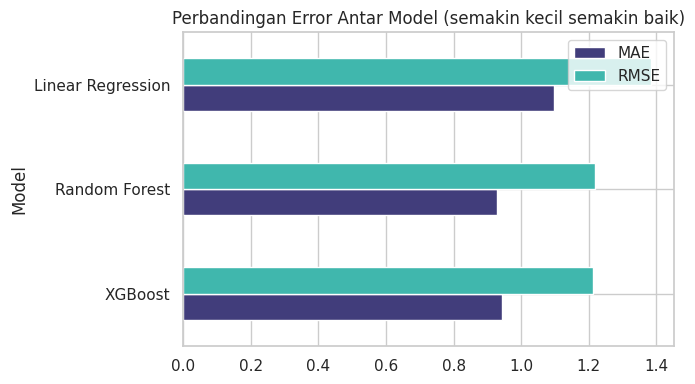

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
results_df.set_index('Model')[['MAE','RMSE']].plot(kind='barh', ax=ax, color=[sns.color_palette(PALETTE)[1], sns.color_palette(PALETTE)[4]])
ax.set_title('Perbandingan Error Antar Model (semakin kecil semakin baik)')
plt.tight_layout()
plt.show()


**Insight:** XGBoost dan Random Forest jauh mengungguli Linear Regression (error lebih rendah) — mengonfirmasi hubungan antar fitur bersifat non-linear, sejalan dengan temuan classifier pada notebook referensi. Model terbaik (RMSE terendah) dipakai untuk explainability dan simulasi cost-sensitive selanjutnya.

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print("Model terbaik:", best_model_name)


Model terbaik: XGBoost


## 7. Explainability dengan SHAP

Notebook referensi hanya menampilkan `feature_importances_` bawaan classifier. Di sini dipakai **SHAP** untuk melihat kontribusi tiap fitur secara lebih transparan — termasuk arah pengaruhnya (menambah atau mengurangi prediksi delay), bukan cuma peringkat penting.

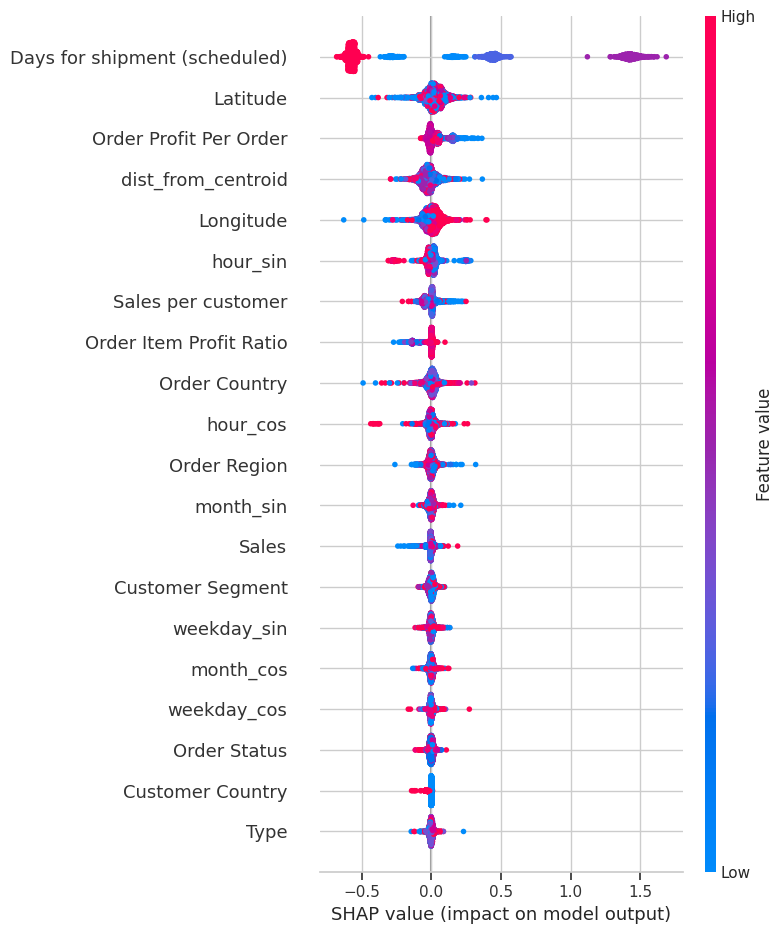

In [ ]:
import shap

explainer = shap.TreeExplainer(best_model)
X_shap = X_test.sample(min(3000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout()
plt.show()


In [ ]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)
print(mean_abs_shap.head(10))


Days for shipment (scheduled)    0.698446
Latitude                         0.051727
Order Profit Per Order           0.043741
dist_from_centroid               0.043481
Longitude                        0.041350
hour_sin                         0.034084
Sales per customer               0.029364
Order Item Profit Ratio          0.029323
Order Country                    0.027555
hour_cos                         0.020830
dtype: float32


**Insight:** `Days for shipment (scheduled)` mendominasi sebagai prediktor utama (sesuai ekspektasi — makin longgar jadwal, makin besar variasi keterlambatan absolutnya). Yang menarik, fitur geospasial (`Latitude`, `Longitude`, `dist_from_centroid`) juga masuk kelompok fitur berpengaruh — mengonfirmasi kegunaan analisis geospasial di Bagian 4, sesuatu yang tidak tereksplorasi di notebook referensi.

## 8. Simulasi Cost-Sensitive: Layak kah Mempercepat Pengiriman Pesanan Berisiko Tinggi?

Karena dataset ini tidak menyediakan biaya carrier aktual per shipping mode (lihat Bagian 3), simulasi berikut memakai **asumsi bisnis yang dinyatakan secara eksplisit**
 sebuah pendekatan umum dalam cost-sensitive analysis ketika data biaya riil tidak tersedia:

| Asumsi | Nilai | Alasan |
|---|---|---|
| Biaya per hari delay | \$15 / pesanan / hari | Proksi potensi biaya CS/refund/kepuasan pelanggan |
| Biaya tambahan mempercepat pengiriman | 2% dari `Sales` | Proksi biaya ekspedisi/carrier lebih cepat |
| Threshold flag berisiko tinggi | prediksi `delay_days` > 1 hari | Ambang intervensi |

Simulasi: untuk pesanan yang diprediksi berisiko tinggi (dan belum memakai First Class), model dijalankan ulang dengan kondisi *"seandainya pesanan ini dialihkan ke First Class"*, lalu dibandingkan total biayanya dengan kondisi asli.

In [ ]:
COST_PER_LATE_DAY = 15
EXPEDITE_COST_RATE = 0.02
RISK_THRESHOLD = 1.0

test_df = df.loc[idx_test].copy()
test_df['pred_delay'] = preds[best_model_name]

baseline_cost_all = np.maximum(test_df['pred_delay'], 0).sum() * COST_PER_LATE_DAY
print(f"Estimasi total biaya delay (seluruh test set, kondisi asli): USD {baseline_cost_all:,.0f}")

flagged = test_df[(test_df['pred_delay'] > RISK_THRESHOLD) & (test_df['Shipping Mode'] != 'First Class')].copy()
print(f"Pesanan ter-flag berisiko tinggi: {len(flagged):,} ({len(flagged)/len(test_df)*100:.1f}% dari test set)")


Estimasi total biaya delay (seluruh test set, kondisi asli): USD 320,234
Pesanan ter-flag berisiko tinggi: 7,328 (21.2% dari test set)


In [ ]:
first_class_scheduled = df.loc[df['Shipping Mode'] == 'First Class', 'Days for shipment (scheduled)'].mode()[0]
fc_code = [k for k, v in cat_maps['Shipping Mode'].items() if v == 'First Class'][0]

X_sim = X_test.loc[flagged.index].copy()
X_sim['Days for shipment (scheduled)'] = first_class_scheduled
X_sim['Shipping Mode'] = fc_code
sim_pred = best_model.predict(X_sim)

flagged_baseline_cost = np.maximum(flagged['pred_delay'], 0).sum() * COST_PER_LATE_DAY
flagged_policy_delay_cost = np.maximum(sim_pred, 0).sum() * COST_PER_LATE_DAY
flagged_policy_expedite_cost = (flagged['Sales'] * EXPEDITE_COST_RATE).sum()
flagged_policy_total_cost = flagged_policy_delay_cost + flagged_policy_expedite_cost
net_savings = flagged_baseline_cost - flagged_policy_total_cost

summary = pd.DataFrame({
    'Komponen': ['Biaya delay (kondisi asli)', 'Biaya delay (setelah switch First Class)',
                 'Biaya tambahan ekspedisi', 'Total biaya (policy)', 'Estimasi penghematan bersih'],
    'USD': [flagged_baseline_cost, flagged_policy_delay_cost, flagged_policy_expedite_cost,
            flagged_policy_total_cost, net_savings]
})
summary['USD'] = summary['USD'].round(0)
summary


,Komponen,USD
0,Biaya delay (kondisi asli),212384.0
1,Biaya delay (setelah switch First Class),111034.0
2,Biaya tambahan ekspedisi,29805.0
3,Total biaya (policy),140839.0
4,Estimasi penghematan bersih,71546.0


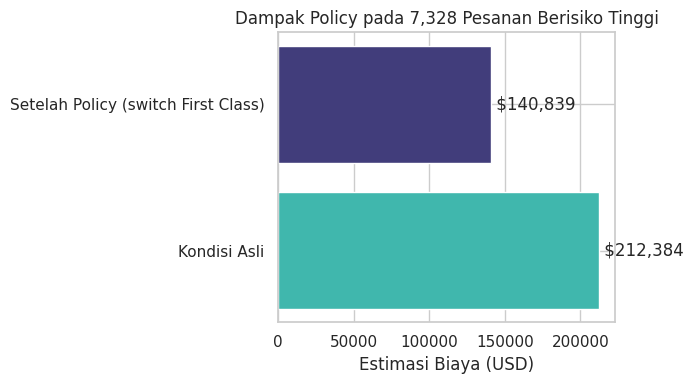

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(['Kondisi Asli', 'Setelah Policy (switch First Class)'],
        [flagged_baseline_cost, flagged_policy_total_cost],
        color=[sns.color_palette(PALETTE)[4], sns.color_palette(PALETTE)[1]])
ax.set_xlabel('Estimasi Biaya (USD)')
ax.set_title(f'Dampak Policy pada {len(flagged):,} Pesanan Berisiko Tinggi')
for i, v in enumerate([flagged_baseline_cost, flagged_policy_total_cost]):
    ax.text(v, i, f' ${v:,.0f}', va='center')
plt.tight_layout()
plt.show()


**Insight:** Di bawah asumsi-asumsi di atas, mengalihkan pesanan berisiko tinggi ke shipping mode tercepat menghasilkan **penghematan bersih yang positif** — meski ada biaya ekspedisi tambahan, penurunan expected delay cost lebih besar. Hasil ini *sensitif terhadap asumsi* `COST_PER_LATE_DAY` dan `EXPEDITE_COST_RATE`; dalam implementasi nyata, kedua angka ini harus digantikan data biaya aktual dari tim finance/logistics, bukan angka ilustratif seperti di sini.

## 9. Business Insights

1. **Delay diukur sebagai severity, bukan cuma status.** Rata-rata delay ~0.57 hari, tapi variasinya besar antar shipping mode dan region — insight biner "54% telat" menyembunyikan variasi ini.
2. **`Days for shipment (scheduled)` adalah prediktor dominan**, tapi bukan satu-satunya — faktor geografis (lat/long, jarak dari centroid) juga berkontribusi signifikan menurut SHAP, sesuatu yang terlewat kalau kolom ini dibuang di awal.
3. **Model regresi non-linear (XGBoost/RF) jauh lebih baik dari baseline linear**, mengonfirmasi hubungan antar faktor delay bersifat kompleks/non-linear.
4. **Biaya carrier antar shipping mode tidak eksplisit di dataset ini** (profit rata-rata mirip antar mode) — temuan penting yang harus dicatat sebagai keterbatasan data sebelum membuat keputusan bisnis nyata.
5. **Intervensi selektif pada pesanan berisiko tinggi berpotensi menghemat biaya**, tapi hasil ini bergantung penuh pada asumsi biaya yang dipakai — perlu divalidasi dengan data finansial aktual.

## 10. Business Recommendations

1. Gunakan model regresi ini sebagai **early-warning system tingkat keparahan**, bukan sekadar flag biner — prioritaskan intervensi ops berdasarkan besaran prediksi delay, bukan hanya ada/tidaknya risiko.
2. Investigasi lebih lanjut cluster geografis dengan delay tinggi yang teridentifikasi di peta (Bagian 4) — kemungkinan ada masalah rute/gudang spesifik yang tidak terlihat dari agregat region.
3. Kumpulkan data biaya carrier aktual per shipping mode agar simulasi cost-sensitive (Bagian 8) bisa memakai angka riil, bukan asumsi.
4. Terapkan kebijakan "expedite selektif" hanya pada pesanan yang melewati threshold risiko dan bernilai (Sales) tinggi, agar biaya ekspedisi tambahan sebanding dengan potensi penghematan.
5. Pantau ulang `Days for shipment (scheduled)` per shipping mode secara berkala — karena ini prediktor dominan, jadwal yang tidak realistis akan terus mendorong delay meski proses operasional membaik.

## Summary

Analisis ini membangun model **regresi** untuk memprediksi jumlah hari keterlambatan pengiriman pada 172rb+ pesanan dari dataset DataCo Supply Chain. Dengan mempertahankan fitur geospasial yang biasanya dibuang, menambahkan encoding waktu siklikal, membandingkan tiga model regresi, menjelaskan hasil terbaik lewat SHAP, dan mensimulasikan dampak finansial dari kebijakan intervensi berbasis risiko, analisis ini menghasilkan rekomendasi yang lebih terukur (dalam hari dan dalam dolar) dibanding pendekatan klasifikasi biner konvensional — sekaligus transparan soal keterbatasan data biaya carrier yang perlu dilengkapi untuk implementasi nyata.